# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>
shape of x_obs:  torch.Size([500, 1])
shape of u_obs:  torch.Size([500, 1])
shape of x_test:  torch.Size([10001, 1])
shape of u_test:  torch.Size([10001, 1])
shape of k_test:  torch.Size([10001, 1])


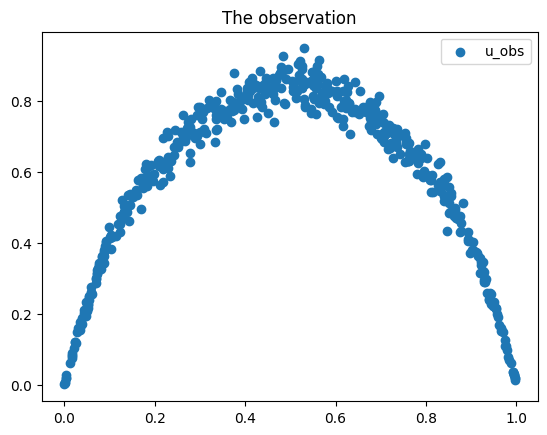

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import grad, Variable
from tqdm import trange
import time
#
dataType = torch.float32
device = 'cuda'
np.random.seed(1234)
torch.manual_seed(1234)
#
with h5py.File('ProblemA_dataset.h5', 'r') as f:
    print(f.keys())
    #
    x_obs = torch.tensor(np.array(f['x_obs']).reshape(-1,1), dtype=dataType)
    u_obs = torch.tensor(np.array(f['u_obs']).reshape(-1,1), dtype=dataType)
    x_test =torch.tensor(np.array(f['x_test']).reshape(-1,1), dtype=dataType)
    u_test =torch.tensor(np.array(f['u_test']).reshape(-1,1), dtype=dataType)
    k_test =torch.tensor(np.array(f['k_test']).reshape(-1,1), dtype=dataType)
#
print('shape of x_obs: ', x_obs.shape)
print('shape of u_obs: ', u_obs.shape)
print('shape of x_test: ', x_test.shape)
print('shape of u_test: ', u_test.shape)
print('shape of k_test: ', k_test.shape)


plt.figure()
plt.scatter(x_obs, u_obs, label='u_obs')
plt.title('The observation')
plt.legend()
plt.show()

Using device: cuda

Keys: <KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>

The shape of x_obs: torch.Size([500, 1])
The shape of u_obs: torch.Size([500, 1])
The shape of x_test: torch.Size([10001, 1])
The shape of u_test: torch.Size([10001, 1])
The shape of k_test: torch.Size([10001, 1])


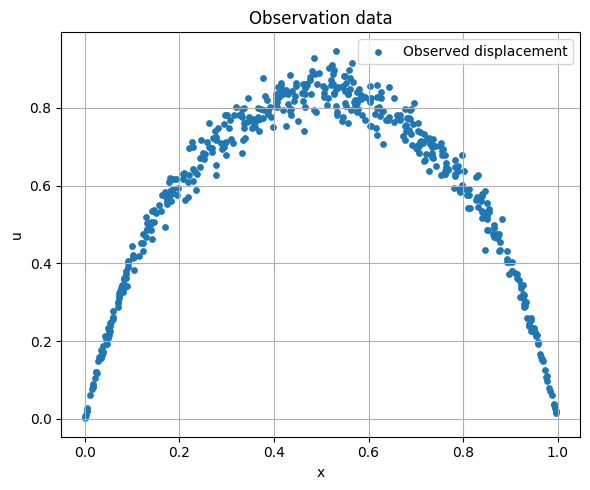

52,862 trainable parameters.
The shape of integral points: torch.Size([100, 1])
The shape of test functions: torch.Size([5, 100, 1])
The shape of test function gradients: torch.Size([5, 100, 1])


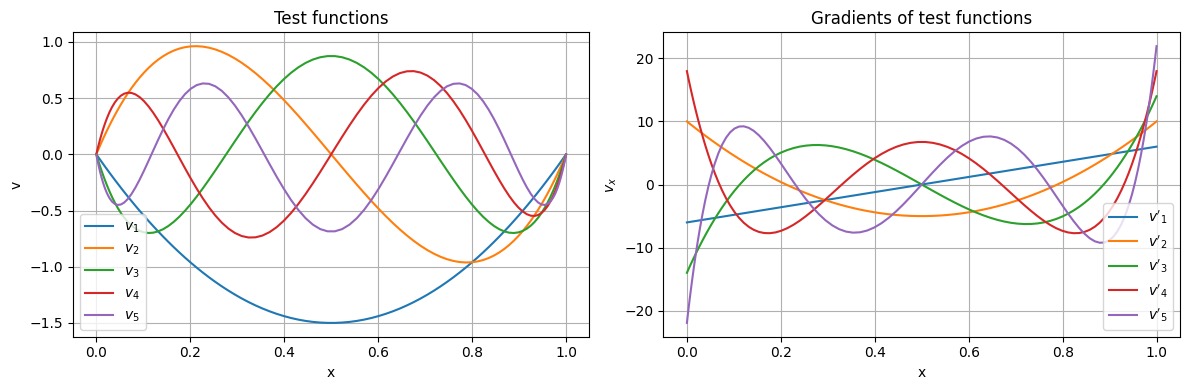

The shape of integral points: torch.Size([10000, 1])
The shape of test functions: torch.Size([100, 10000, 1])
The shape of test function gradients: torch.Size([100, 10000, 1])


 10%|█         | 2025/20000 [00:10<01:42, 174.85it/s]

Epoch:2000, loss:1.061450e-03, pde:4.110735e-05, obs:9.586811e-04, error_u:1.519867e-02, error_k:1.359876e-01, best_error_k:1.359876e-01, lr:6.667e-04


 20%|██        | 4027/20000 [00:22<01:23, 191.58it/s]

Epoch:4000, loss:8.892782e-04, pde:2.074423e-06, obs:8.840922e-04, error_u:6.908763e-03, error_k:8.282444e-02, best_error_k:8.228396e-02, lr:4.444e-04


...

Epoch:16000, loss:8.621260e-04, pde:1.421106e-08, obs:8.620905e-04, error_u:3.456731e-03, error_k:4.085152e-02, best_error_k:4.085152e-02, lr:3.902e-05


 90%|█████████ | 18037/20000 [01:37<00:10, 188.20it/s]

Epoch:18000, loss:8.619069e-04, pde:9.579216e-09, obs:8.618830e-04, error_u:3.486354e-03, error_k:3.961693e-02, best_error_k:3.961693e-02, lr:2.601e-05


100%|██████████| 20000/20000 [01:47<00:00, 185.63it/s]


Epoch:20000, loss:8.617318e-04, pde:2.189492e-08, obs:8.616771e-04, error_u:3.510296e-03, error_k:3.866016e-02, best_error_k:3.866016e-02, lr:1.734e-05
Training time: 107.74205040931702
Best test L2 relative error for k: 0.03866015747189522
Final L2 relative error for u: 0.0035102958790957928
Final L2 relative error for k: 0.03866015747189522


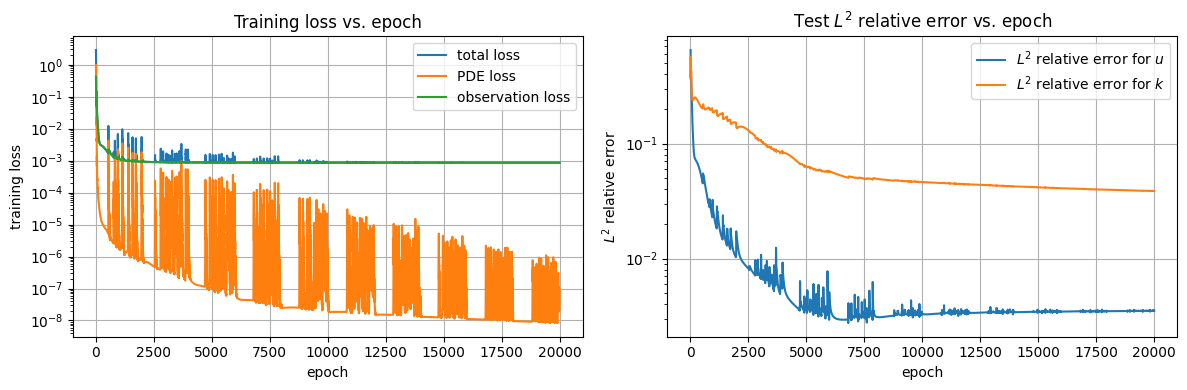

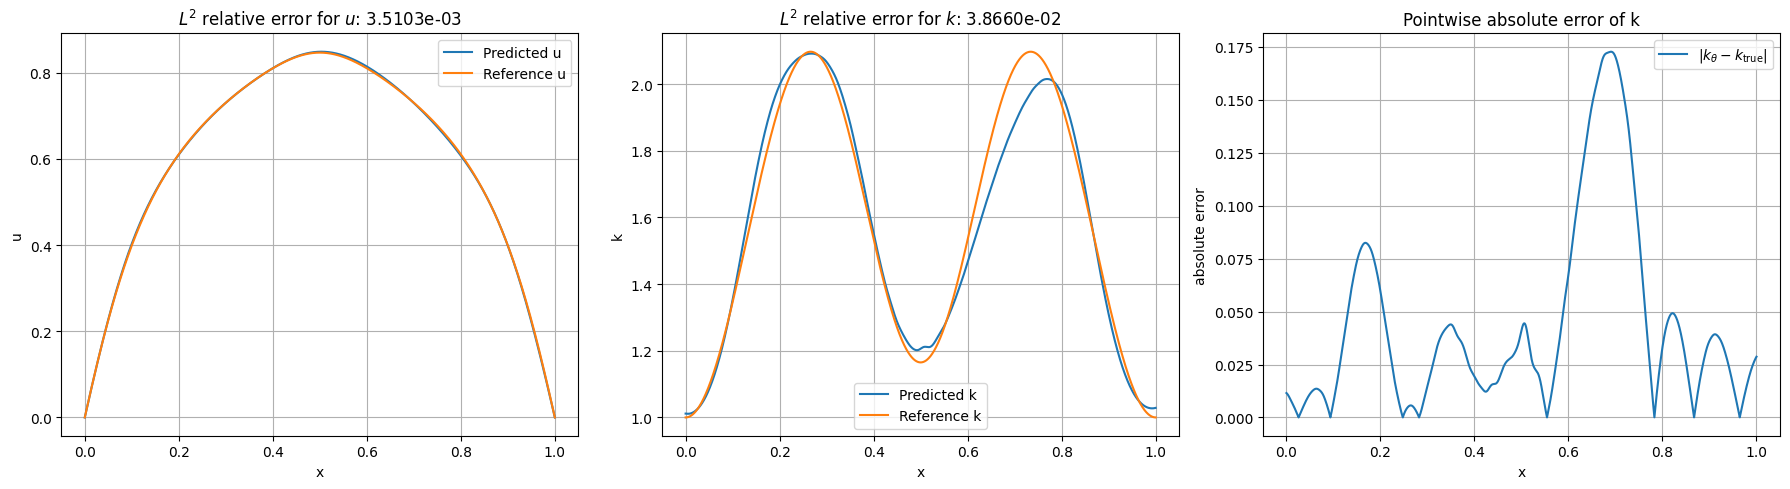

In [1]:
#############################################################
# Problem A: Recover Young's modulus k(x) in 1D Elastostatics
# Method: Weak-form physics-informed inverse learning
#############################################################


#############################################################
# Step 0: Import packages and global settings
#############################################################

import time
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm import trange
from torch.autograd import grad
from scipy.special import eval_jacobi


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

np.random.seed(1234)
torch.manual_seed(1234)

if device.type == "cuda":
    torch.cuda.manual_seed_all(1234)
    torch.backends.cudnn.benchmark = True

print("Using device:", device)


#############################################################
# Step 1: Load dataset
#############################################################

with h5py.File("ProblemA_dataset.h5", "r") as data:
    print("\nKeys:", data.keys())

    x_obs = torch.tensor(np.array(data["x_obs"]).reshape(-1, 1), dtype=dtype)
    u_obs = torch.tensor(np.array(data["u_obs"]).reshape(-1, 1), dtype=dtype)
    x_test = torch.tensor(np.array(data["x_test"]).reshape(-1, 1), dtype=dtype)
    u_test = torch.tensor(np.array(data["u_test"]).reshape(-1, 1), dtype=dtype)
    k_test = torch.tensor(np.array(data["k_test"]).reshape(-1, 1), dtype=dtype)

print("\nThe shape of x_obs:", x_obs.shape)
print("The shape of u_obs:", u_obs.shape)
print("The shape of x_test:", x_test.shape)
print("The shape of u_test:", u_test.shape)
print("The shape of k_test:", k_test.shape)


#############################################################
# Step 2: Visualize observation data
#############################################################

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.scatter(x_obs, u_obs, s=15, label="Observed displacement")
ax.set_title("Observation data")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 3: Define MLP models for u(x) and k(x)
#############################################################

class MLP_u(nn.Module):

    def __init__(self, layers_list: list, dtype=None):
        super(MLP_u, self).__init__()
        """
        MLP for approximating displacement field u(x).
        Input:
            x: shape (N, 1)
        Return:
            u: shape (N, 1)
        """
        net = []

        self.hidden_in = layers_list[0]

        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=dtype))
            self.hidden_in = hidden

        self.net = nn.Sequential(*net)

    def forward(self, x):
        """
        Input:
            x: shape (N, 1)
        Return:
            u: shape (N, 1)
        Hard boundary condition:
            u_theta(x) = x(1-x) N_theta(x)
            so that u(0)=u(1)=0.
        """

        x_input = x

        for layer in self.net[:-1]:
            x = layer(x)
            x = torch.sin(np.pi * x + np.pi) + torch.sin(x)

        raw = self.net[-1](x)

        u = x_input * (1.0 - x_input) * raw

        return u


class FourierFeatures1D(nn.Module):

    def __init__(self, frequencies):
        super(FourierFeatures1D, self).__init__()
        """
        Input:
            x: shape (N, 1)
        Return:
            features: shape (N, 1 + 2 * len(frequencies))
        Function:
            Map x to Fourier features:
                [x, sin(2*pi*f*x), cos(2*pi*f*x)]
        """

        self.frequencies = torch.tensor(frequencies, dtype=dtype).reshape(1, -1)

    def forward(self, x):
        """
        Input:
            x: shape (N, 1)
        Return:
            features: shape (N, 1 + 2*num_freq)
        """
        freq = self.frequencies.to(x.device)

        x_freq = 2.0 * torch.pi * x @ freq
        features = torch.cat([x, torch.sin(x_freq), torch.cos(x_freq)], dim=1)

        return features
    

class MLP_k(nn.Module):

    def __init__(self, layers_list: list, frequencies=None, dtype=None):
        super(MLP_k, self).__init__()
        """
        MLP with Fourier features for approximating Young's modulus k(x).
        Input:
            x: shape (N, 1)
        Return:
            k: shape (N, 1), positive due to softplus
        """

        if frequencies is None:
            frequencies = [1, 2, 4, 8, 16]

        self.embedding = FourierFeatures1D(frequencies=frequencies)

        net = []
        self.hidden_in = layers_list[0]

        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=dtype))
            self.hidden_in = hidden

        self.net = nn.Sequential(*net)

    def forward(self, x):
        """
        Input:
            x: shape (N, 1)
        Return:
            k: shape (N, 1), positive
        """

        x = self.embedding(x)

        for layer in self.net[:-1]:
            x = layer(x)
            x = torch.tanh(x)

        raw = self.net[-1](x)
        k = nn.functional.softplus(raw)

        return k


#############################################################
# Step 4: Create models
#############################################################

layers_u = [1, 60, 60, 60, 60, 1]
frequencies_k = [1, 2, 4, 8, 16]
input_dim_k = 1 + 2 * len(frequencies_k)
layers_k = [input_dim_k, 100, 100, 100, 100, 100, 1]

model_u = MLP_u(layers_u, dtype=dtype).to(device)
model_k = MLP_k(layers_k, frequencies=frequencies_k, dtype=dtype).to(device)

total_trainable_params = (sum(p.numel() for p in model_u.parameters() if p.requires_grad) + sum(p.numel() for p in model_k.parameters() if p.requires_grad))
print(f"{total_trainable_params:,} trainable parameters.")


#############################################################
# Step 5: Define Jacobi test functions for weak form
#############################################################

def Jacobi(n, a, b, x):
    """
    Evaluate Jacobi polynomial P_n^{(a,b)}(x).
    Input:
        n: polynomial order
        a,b: Jacobi parameters
        x: torch tensor, shape (N, 1)
    Return:
        p: torch tensor, shape (N, 1)
    """

    x_np = x.detach().cpu().numpy()
    p_np = eval_jacobi(n, a, b, x_np)
    p = torch.tensor(p_np, dtype=dtype, device=device)

    return p


class TestFun(object):

    def __init__(self, N_test: int):
        """
        Input:
            N_test: number of test functions
        """

        self.N_test = N_test

    def get_v(self, xi):
        """
        Input:
            xi: shape (N_int, 1), points in reference interval [-1,1]
        Return:
            v: shape (N_test, N_int, 1)
        Test functions:
            v_n = P_{n+1}(xi) - P_{n-1}(xi)
        They vanish at xi=-1 and xi=1.
        """

        v_total = []

        for n in range(1, self.N_test + 1):
            v = (Jacobi(n + 1, 0, 0, xi) - Jacobi(n - 1, 0, 0, xi))
            v_total.append(v)

        v_total = torch.stack(v_total, dim=0)

        return v_total

    def get_dv(self, xi):
        """
        Input:
            xi: shape (N_int, 1), points in reference interval [-1,1]
        Return:
            dv_dxi: shape (N_test, N_int, 1)
        Derivative with respect to xi.
        """

        dv_total = []

        for n in range(1, self.N_test + 1):
            if n == 1:
                dv = ((n + 2) / 2.0) * Jacobi(n, 1, 1, xi)
            else:
                dv = (((n + 2) / 2.0) * Jacobi(n, 1, 1, xi) - (n / 2.0) * Jacobi(n - 2, 1, 1, xi))
            dv_total.append(dv)

        dv_total = torch.stack(dv_total, dim=0)

        return dv_total


#############################################################
# Step 6: Define loss class
#############################################################

class LossClass(object):

    def __init__(self, u_model, k_model, N_test: int, f_value=9.81):
        """
        Args:
            u_model : neural network for u(x)
            k_model : neural network for k(x)
            N_test  : number of weak-form test functions
            f_value : body force
        """

        self.device = device

        self.u_model = u_model
        self.k_model = k_model

        self.GetTest = TestFun(N_test)

        self.mse = nn.MSELoss()

        self.f_value = f_value

    def get_test(self, N_int: int, lb, ub):
        """
        Generate Gauss quadrature points and test functions.

        Input:
            N_int: number of quadrature points
            lb, ub: domain boundary
        Return:
            x:  physical quadrature points, shape (N_int, 1)
            w:  physical quadrature weights, shape (N_int, 1)
            v:  test functions, shape (N_test, N_int, 1)
            dv: derivative with respect to physical x, shape (N_test, N_int, 1)
        """

        xi_int, w_int = np.polynomial.legendre.leggauss(N_int)

        xi_int = torch.tensor(xi_int.reshape(-1, 1), dtype=dtype, device=device)
        w_int = torch.tensor(w_int.reshape(-1, 1), dtype=dtype, device=device)

        lb_value = lb[0]
        ub_value = ub[0]

        x = xi_int * (ub_value - lb_value) / 2.0 + (ub_value + lb_value) / 2.0
        w = w_int * (ub_value - lb_value) / 2.0
        v = self.GetTest.get_v(xi_int)

        dv_dxi = self.GetTest.get_dv(xi_int)
        dv = dv_dxi * 2.0 / (ub_value - lb_value)

        print("The shape of integral points:", x.shape)
        print("The shape of test functions:", v.shape)
        print("The shape of test function gradients:", dv.shape)

        return x, w, v, dv

    def loss_obs(self, x_obs, u_obs):
        """
        Observation loss:
            L_obs = mean |u_theta(x_obs) - u_obs|^2

        Input:
            x_obs: shape (N_obs, 1)
            u_obs: shape (N_obs, 1)
        Return:
            loss_obs: scalar
        """

        x = x_obs.to(self.device)
        u_true = u_obs.to(self.device)

        u_pred = self.u_model(x)

        loss = self.mse(u_pred, u_true)

        return loss

    def loss_pde(self, x, w, v, dv):
        """
        Weak-form PDE loss.
        PDE:
            - d/dx ( k(x) u_x(x) ) = f
        Weak form:
            integral k u_x v_x dx = integral f v dx

        Input:
            x : shape (N_int, 1)
            w : shape (N_int, 1)
            v : shape (N_test, N_int, 1)
            dv: shape (N_test, N_int, 1)
        Return:
            loss_pde: scalar
        """

        x = x.reshape(-1, 1).clone().detach().to(self.device)
        x.requires_grad_(True)

        w = w.to(self.device)
        v = v.to(self.device)
        dv = dv.to(self.device)

        u = self.u_model(x)
        du_dx = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        k = self.k_model(x)

        left = torch.sum(k * du_dx * dv * w, dim=1)
        right = torch.sum(self.f_value * v * w, dim=1)

        loss = torch.mean((left - right) ** 2)

        return loss

    def loss_total(self, x_obs, u_obs, x_int, w_int, v_int, dv_int, w_pde, w_obs):
        """
        Total loss:
            L = w_pde * L_pde + w_obs * L_obs
        Boundary condition is enforced by hard BC in MLP_u.
        """

        loss_pde = self.loss_pde(x_int, w_int, v_int, dv_int)
        loss_obs = self.loss_obs(x_obs, u_obs)

        loss = (w_pde * loss_pde + w_obs * loss_obs)

        return loss, loss_pde, loss_obs

    def get_error(self, x_test, u_test, k_test):
        """
        Compute L2 relative errors for u and k.
        Input:
            x_test: shape (N_test, 1)
            u_test: shape (N_test, 1)
            k_test: shape (N_test, 1)
        Return:
            error_u, error_k: Python floats
        """

        self.u_model.eval()
        self.k_model.eval()

        x = x_test.to(self.device)
        u_true = u_test.to(self.device)
        k_true = k_test.to(self.device)

        with torch.inference_mode():

            u_pred = self.u_model(x)
            k_pred = self.k_model(x)

            error_u = torch.sqrt(
                torch.sum((u_pred - u_true) ** 2)
                /
                torch.sum(u_true ** 2)
            )

            error_k = torch.sqrt(
                torch.sum((k_pred - k_true) ** 2)
                /
                torch.sum(k_true ** 2)
            )

        self.u_model.train()
        self.k_model.train()

        return error_u.item(), error_k.item()

    def predict(self, x_query):
        """
        Predict u(x) and k(x).

        Input:
            x_query: shape (N, 1)
        Return:
            u_pred, k_pred: CPU tensors, shape (N, 1)
        """

        self.u_model.eval()
        self.k_model.eval()

        x = x_query.to(self.device)

        with torch.inference_mode():
            u_pred = self.u_model(x).detach().cpu()
            k_pred = self.k_model(x).detach().cpu()

        self.u_model.train()
        self.k_model.train()

        return u_pred, k_pred


#############################################################
# Step 7: Visualize test functions
#############################################################

lb = [0.0]
ub = [1.0]

lossClass = LossClass(model_u, model_k, N_test=5)

x_int_plot, w_int_plot, v_plot, dv_plot = lossClass.get_test(N_int=100, lb=lb, ub=ub)

x_int_plot_cpu = x_int_plot.detach().cpu()
v_plot_cpu = v_plot.detach().cpu()
dv_plot_cpu = dv_plot.detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(5):
    axes[0].plot(x_int_plot_cpu, v_plot_cpu[i, :, 0], label=rf"$v_{i+1}$")

axes[0].set_title("Test functions")
axes[0].set_xlabel("x")
axes[0].set_ylabel("v")
axes[0].legend()
axes[0].grid(True)

for i in range(5):
    axes[1].plot(x_int_plot_cpu, dv_plot_cpu[i, :, 0], label=rf"$v'_{i+1}$")

axes[1].set_title("Gradients of test functions")
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$v_x$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 8: Training setup
#############################################################

epochs = 20000
eval_interval = 5

lr = 1e-3
weight_decay = 0.0

w_pde = 2.5
w_obs = 1.0

N_test = 100
N_int = 10000

model_u = MLP_u(layers_u, dtype=dtype).to(device)
model_k = MLP_k(layers_k, frequencies=frequencies_k, dtype=dtype).to(device)

optimizer = torch.optim.Adam(params=list(model_u.parameters()) + list(model_k.parameters()), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs / 10), gamma=2.0 / 3.0)

lossClass = LossClass(model_u, model_k, N_test=N_test)
x_int, w_int, v_int, dv_int = lossClass.get_test(N_int=N_int, lb=lb, ub=ub)

loss_list = []
loss_pde_list = []
loss_obs_list = []

error_u_list = []
error_k_list = []
eval_epochs = []

best_error_k = float("inf")
best_state_u = None
best_state_k = None


#############################################################
# Step 9: Training process
#############################################################

t0 = time.time()

for epoch in trange(epochs):

    model_u.train()
    model_k.train()

    loss_train, loss_pde, loss_obs = lossClass.loss_total(x_obs, u_obs, x_int, w_int, v_int, dv_int, w_pde=w_pde, w_obs=w_obs)

    optimizer.zero_grad(set_to_none=True)
    loss_train.backward()
    torch.nn.utils.clip_grad_norm_(list(model_u.parameters()) + list(model_k.parameters()), max_norm=5.0)
    optimizer.step()
    scheduler.step()

    loss_list.append(loss_train.item())
    loss_pde_list.append(loss_pde.item())
    loss_obs_list.append(loss_obs.item())

    if (epoch + 1) % eval_interval == 0:
        error_u, error_k = lossClass.get_error(x_test, u_test, k_test)
        
        error_u_list.append(error_u)
        error_k_list.append(error_k)
        eval_epochs.append(epoch + 1)

        if error_k < best_error_k:
            best_error_k = error_k
            best_state_u = {
                key: value.detach().cpu().clone()
                for key, value in model_u.state_dict().items()
            }
            best_state_k = {
                key: value.detach().cpu().clone()
                for key, value in model_k.state_dict().items()
            }

    if (epoch + 1) % 2000 == 0:
        print(
            f"Epoch:{epoch+1}, "
            f"loss:{loss_train.item():.6e}, "
            f"pde:{loss_pde.item():.6e}, "
            f"obs:{loss_obs.item():.6e}, "
            f"error_u:{error_u_list[-1]:.6e}, "
            f"error_k:{error_k_list[-1]:.6e}, "
            f"best_error_k:{best_error_k:.6e}, "
            f"lr:{optimizer.param_groups[0]['lr']:.3e}"
        )

print("Training time:", time.time() - t0)


#############################################################
# Step 10: Load best model
#############################################################

if best_state_u is not None:

    model_u.load_state_dict(
        {
            key: value.to(device)
            for key, value in best_state_u.items()
        }
    )

if best_state_k is not None:

    model_k.load_state_dict(
        {
            key: value.to(device)
            for key, value in best_state_k.items()
        }
    )

print("Best test L2 relative error for k:", best_error_k)


#############################################################
# Step 11: Final prediction and final L2 relative error
#############################################################

u_pred, k_pred = lossClass.predict(x_test)

u_test_cpu = u_test.detach().cpu()
k_test_cpu = k_test.detach().cpu()

error_u = torch.sqrt(
    torch.sum((u_pred - u_test_cpu) ** 2)
    /
    torch.sum(u_test_cpu ** 2)
)

error_k = torch.sqrt(
    torch.sum((k_pred - k_test_cpu) ** 2)
    /
    torch.sum(k_test_cpu ** 2)
)

print("Final L2 relative error for u:", error_u.item())
print("Final L2 relative error for k:", error_k.item())


#############################################################
# Step 12: Plot loss and error curves
#############################################################

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(1, len(loss_list) + 1), loss_list, label="total loss")
axes[0].semilogy(np.arange(1, len(loss_pde_list) + 1), loss_pde_list, label="PDE loss")
axes[0].semilogy(np.arange(1, len(loss_obs_list) + 1), loss_obs_list, label="observation loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss vs. epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(eval_epochs, error_u_list, label=r"$L^2$ relative error for $u$")
axes[1].semilogy(eval_epochs, error_k_list, label=r"$L^2$ relative error for $k$")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(r"$L^2$ relative error")
axes[1].set_title(r"Test $L^2$ relative error vs. epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 13: Visualize prediction and pointwise error
#############################################################

abs_error_u = torch.abs(u_pred - u_test_cpu)
abs_error_k = torch.abs(k_pred - k_test_cpu)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(x_test, u_pred, label="Predicted u")
axes[0].plot(x_test, u_test_cpu, label="Reference u")
axes[0].set_title(rf"$L^2$ relative error for $u$: {error_u.item():.4e}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(x_test, k_pred, label="Predicted k")
axes[1].plot(x_test, k_test_cpu, label="Reference k")
axes[1].set_title(rf"$L^2$ relative error for $k$: {error_k.item():.4e}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("k")
axes[1].legend()
axes[1].grid(True)


axes[2].plot(x_test, abs_error_k, label=r"$|k_{\theta}-k_{\mathrm{true}}|$")
axes[2].set_title("Pointwise absolute error of k")
axes[2].set_xlabel("x")
axes[2].set_ylabel("absolute error")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()